# V-Beam Thermal Sensor - Data Inspection

Exploratory analysis of `Dataset_complet_5.11.2025.xlsx`.

**Sections:**
1. Load data
2. Dataset overview (stats, dtypes, missing values)
3. Correlation matrices (all variables + geometry sub-set)
4. Scatter matrix
5. Variable distributions
6. Scatter plots: ΔTemp vs Sensor Displacement colored by each geometry parameter
7. Normalised box plots

## 1. Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## 2. Load Data

In [27]:
EXCEL_PATH = "../Data/Datasets/Dataset_complet_5.11.2025.xlsx"

df_raw = pd.read_excel(EXCEL_PATH)
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns:\n{df_raw.columns.tolist()}")

INPUT_COLS  = ["Beta Angle", "Beam Length", "Beam Width",
               "Delta Temp", "Young's Modulus - E", "CTE - alpha"]
OUTPUT_COLS = ["Sensor Displacement", "Max Mechanical Stress", "Vol"]

df = df_raw[INPUT_COLS + OUTPUT_COLS].dropna().reset_index(drop=True)
print(f"\nClean rows: {len(df)}")

geom   = df[["Beta Angle", "Beam Length", "Beam Width"]]       
inputs = df[["Delta Temp", "Sensor Displacement"]]              
outputs = df[OUTPUT_COLS]                                       

print("\nHead:")
print(df.head())

Raw dataset shape: (3000, 30)
Columns:
['Design Point', 'P2', 'Delta Temp', 'P7', 'Beta Angle', 'Anchor Displacement', 'Beam Length', 'Beam Width', 'Sensor Displacement', "Young's Modulus - E", 'CTE - alpha', 'Section Area - A', 'Section Modulus - Wz', 'Second Moment of Area - Iz', 'Thermal Load - ThL', 'Horizontal Reaction Force - H', 'Reaction Moment - M', 'Shear Force - T', 'Axial Stress - SigmaA', 'Shear Stress - TauS', 'Bending Stress - SigmaB', 'Equivalent Stress - SigmaEq', 'Stress Factor - average =', 'Vol', 'Vol Factor - average =', 'Structure Volume', 'Max Mechanical Stress', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']

Clean rows: 3000

Head:
   Beta Angle  Beam Length  Beam Width  Delta Temp  Young's Modulus - E  \
0        39.9         34.6         2.0        61.6                71000   
1        26.5         34.9         2.0        31.9                71000   
2        31.9         34.6         2.0        52.4                71000   
3        23.9         34.8         2.

## 3. Dataset Overview

In [28]:
print("---- Statistics ----")
print(df.describe().T.to_string())
print()
print("---- Dataset type and completeness ----")
info = pd.DataFrame({
    "dtype"  : df.dtypes,
    "missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
})
print(info.to_string())

---- Statistics ----
                        count          mean           std           min           25%           50%           75%           max
Beta Angle             3000.0     24.993200  8.670222e+00     10.000000     17.600000     24.850000     32.500000     40.000000
Beam Length            3000.0     27.510467  4.281793e+00     20.000000     23.800000     27.600000     31.200000     35.000000
Beam Width             3000.0      1.499800  2.955826e-01      1.000000      1.200000      1.500000      1.800000      2.000000
Delta Temp             3000.0     45.292500  1.444617e+01     20.000000     32.800000     45.100000     57.900000     70.000000
Young's Modulus - E    3000.0  71000.000000  0.000000e+00  71000.000000  71000.000000  71000.000000  71000.000000  71000.000000
CTE - alpha            3000.0      0.000023  3.388697e-21      0.000023      0.000023      0.000023      0.000023      0.000023
Sensor Displacement    3000.0      0.090790  4.219279e-02      0.024984      0.0597

## 4. Correlation Matrix

Correlation matrix:
                       Beta Angle  Beam Length  Beam Width  Delta Temp  Sensor Displacement  Max Mechanical Stress    Vol
Beta Angle                  1.000       -0.020      -0.024      -0.003               -0.495                 -0.116 -0.008
Beam Length                -0.020        1.000      -0.001       0.046                0.277                 -0.032  0.585
Beam Width                 -0.024       -0.001       1.000      -0.007               -0.012                  0.198  0.802
Delta Temp                 -0.003        0.046      -0.007       1.000                0.696                  0.956  0.022
Sensor Displacement        -0.495        0.277      -0.012       0.696                1.000                  0.737  0.144
Max Mechanical Stress      -0.116       -0.032       0.198       0.956                0.737                  1.000  0.135
Vol                        -0.008        0.585       0.802       0.022                0.144                  0.135  1.000


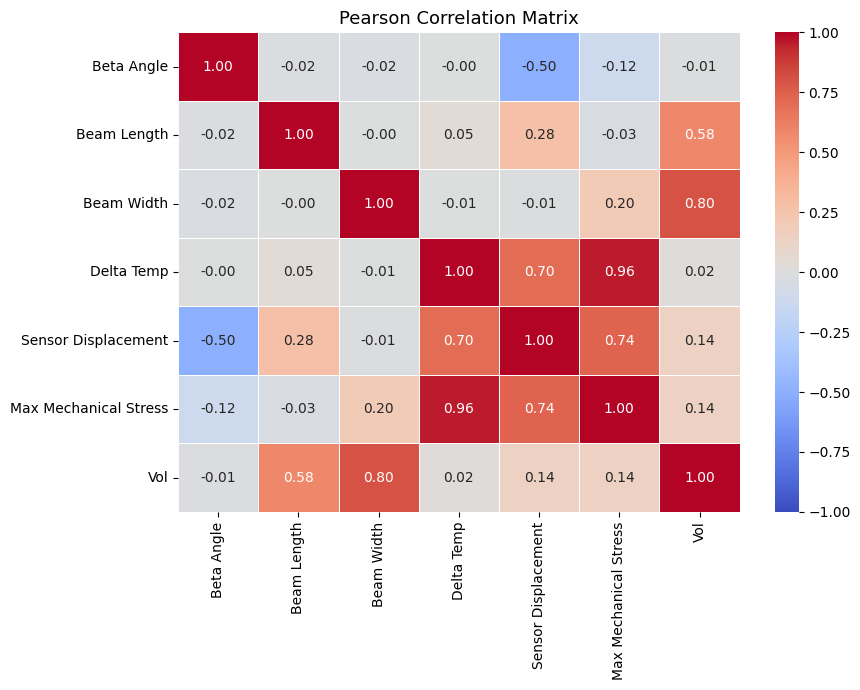

In [29]:
corr = df[["Beta Angle", "Beam Length", "Beam Width",
           "Delta Temp", "Sensor Displacement", "Max Mechanical Stress", "Vol"]].corr()

print("Correlation matrix:")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

Geometry parameter correlation:
             Beta Angle  Beam Length  Beam Width
Beta Angle       1.0000      -0.0202     -0.0235
Beam Length     -0.0202       1.0000     -0.0006
Beam Width      -0.0235      -0.0006      1.0000


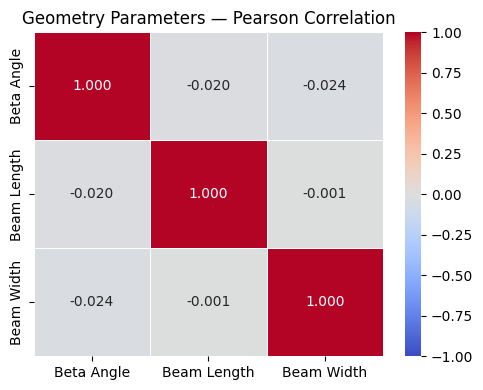

In [30]:
geom_corr = geom.corr('pearson')
print("Geometry parameter correlation:")
print(geom_corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(geom_corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Geometry Parameters — Pearson Correlation", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Scatter Matrix

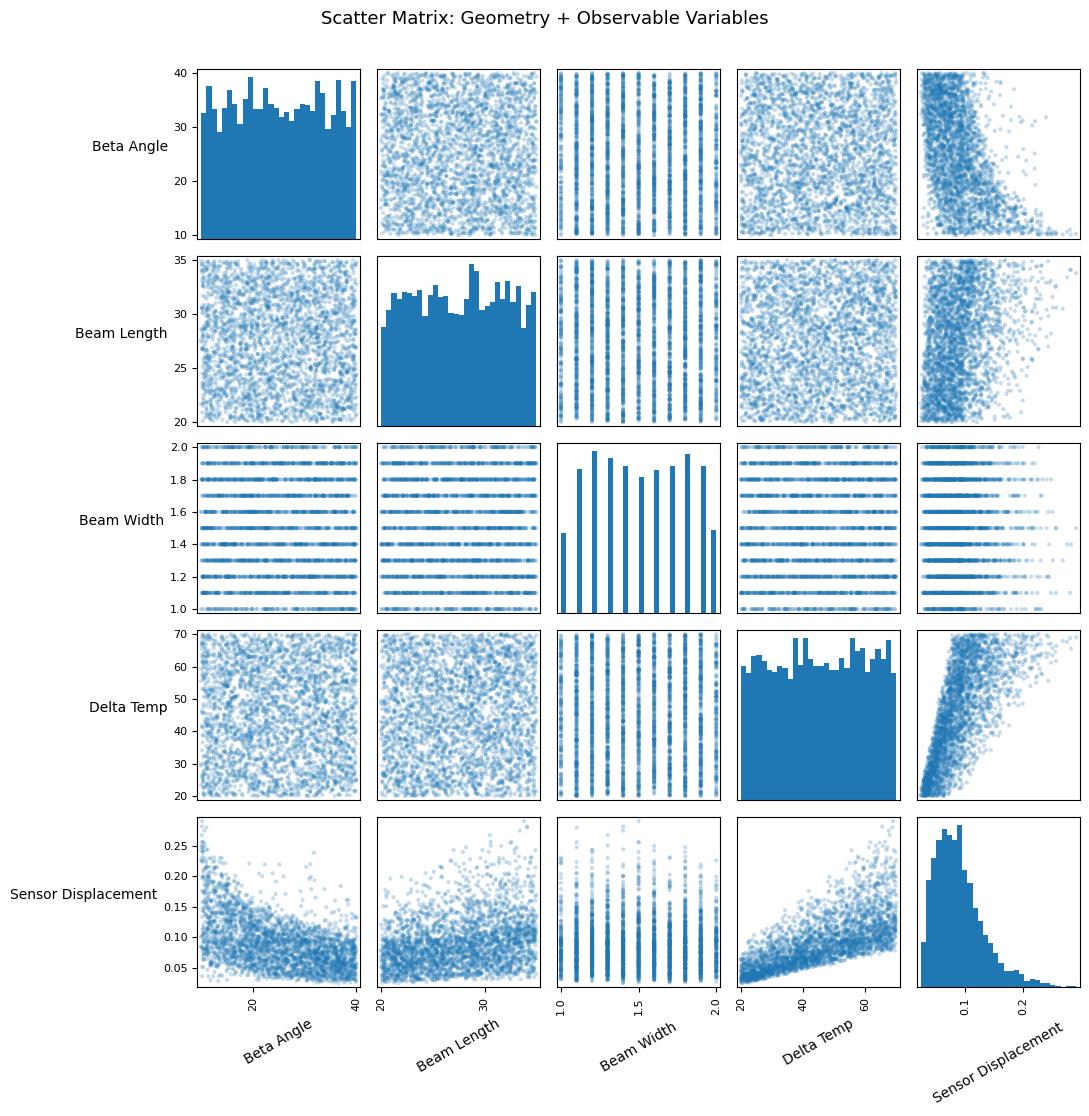

In [31]:
key_cols = ["Beta Angle", "Beam Length", "Beam Width", "Delta Temp", "Sensor Displacement"]
axes = pd.plotting.scatter_matrix(df[key_cols], figsize=(11, 11),
                                   alpha=0.25, diagonal="hist",
                                   hist_kwds={"bins": 30})
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(30)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha("right")
plt.suptitle("Scatter Matrix: Geometry + Observable Variables", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Variable Distributions

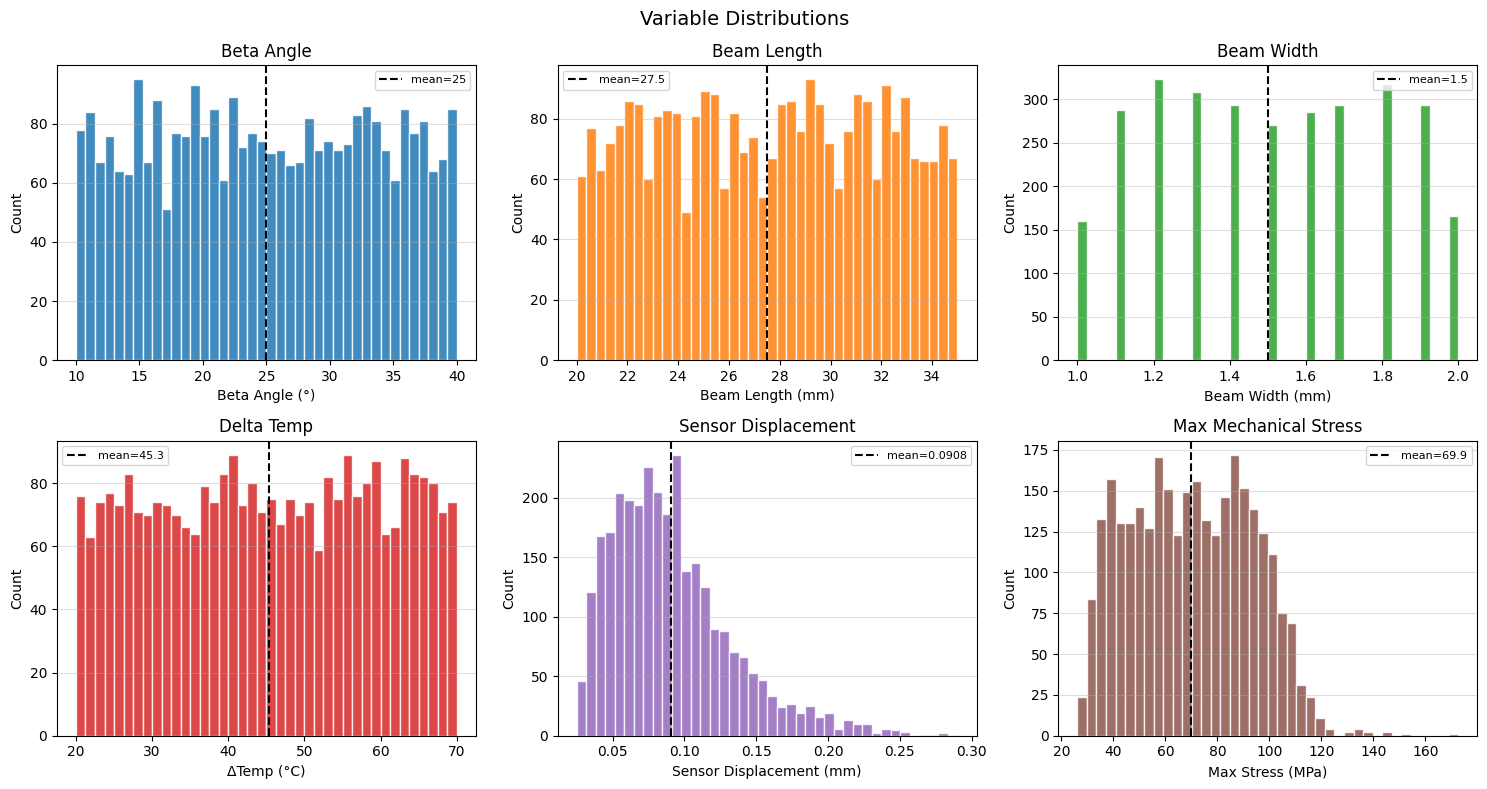

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = [("Beta Angle",         "Beta Angle (°)",        "tab:blue"),
             ("Beam Length",         "Beam Length (mm)",       "tab:orange"),
             ("Beam Width",          "Beam Width (mm)",        "tab:green"),
             ("Delta Temp",          "ΔTemp (°C)",             "tab:red"),
             ("Sensor Displacement", "Sensor Displacement (mm)","tab:purple"),
             ("Max Mechanical Stress","Max Stress (MPa)",      "tab:brown")]

for ax, (col, xlabel, color) in zip(axes.flat, plot_cols):
    ax.hist(df[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_xlabel(xlabel); ax.set_ylabel("Count"); ax.set_title(col)
    ax.axvline(df[col].mean(), color="black", lw=1.5, linestyle="--",
               label=f"mean={df[col].mean():.3g}")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.4)

plt.suptitle("Variable Distributions", fontsize=14)
plt.tight_layout(); plt.show()

## 7. Sensor Displacement vs ΔTemp - Colored by Geometry

Each plot shows how a geometry parameter partitions the (ΔTemp, Displacement) space.

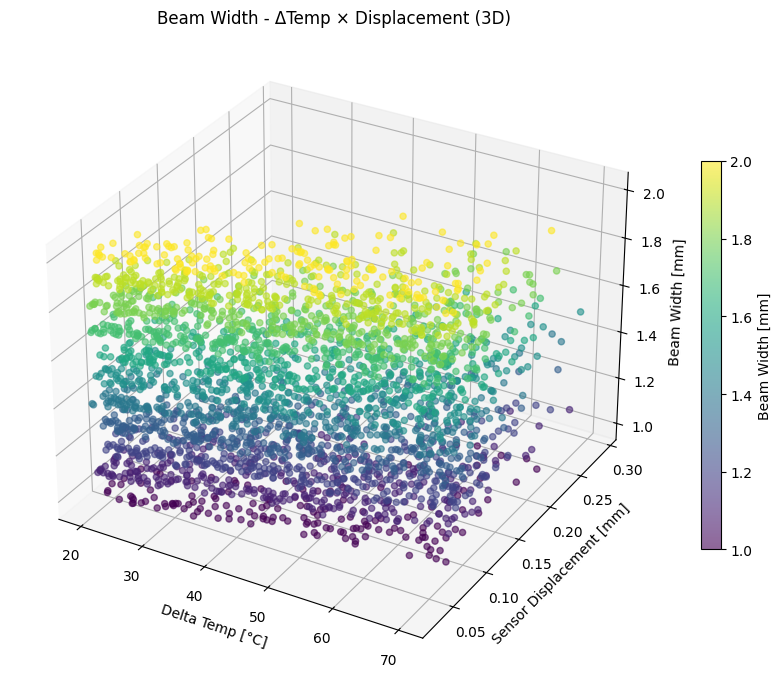

In [33]:
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df["Delta Temp"],
    df["Sensor Displacement"],
    df["Beam Width"],
    c=df["Beam Width"], cmap="viridis", s=20, alpha=0.6
)
ax.set_xlabel("Delta Temp [°C]")
ax.set_ylabel("Sensor Displacement [mm]")
ax.set_zlabel("Beam Width [mm]")
ax.set_title("Beam Width - ΔTemp × Displacement (3D)")
fig.colorbar(sc, ax=ax, label="Beam Width [mm]", shrink=0.6)
plt.tight_layout(); plt.show()

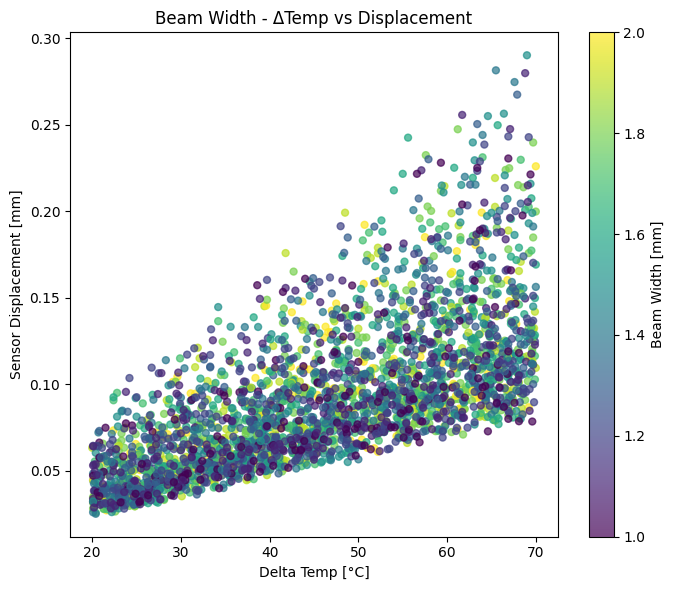

In [34]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    df["Delta Temp"],
    df["Sensor Displacement"],
    c=df["Beam Width"], cmap="viridis", s=25, alpha=0.7
)
plt.xlabel("Delta Temp [°C]")
plt.ylabel("Sensor Displacement [mm]")
plt.title("Beam Width - ΔTemp vs Displacement")
plt.colorbar(sc, label="Beam Width [mm]")
plt.tight_layout(); plt.show()

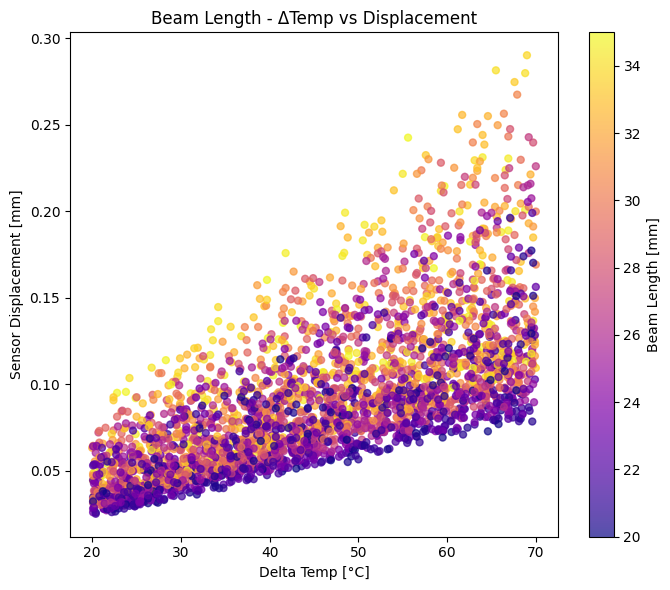

In [35]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    df["Delta Temp"],
    df["Sensor Displacement"],
    c=df["Beam Length"], cmap="plasma", s=25, alpha=0.7
)
plt.xlabel("Delta Temp [°C]")
plt.ylabel("Sensor Displacement [mm]")
plt.title("Beam Length - ΔTemp vs Displacement")
plt.colorbar(sc, label="Beam Length [mm]")
plt.tight_layout(); plt.show()

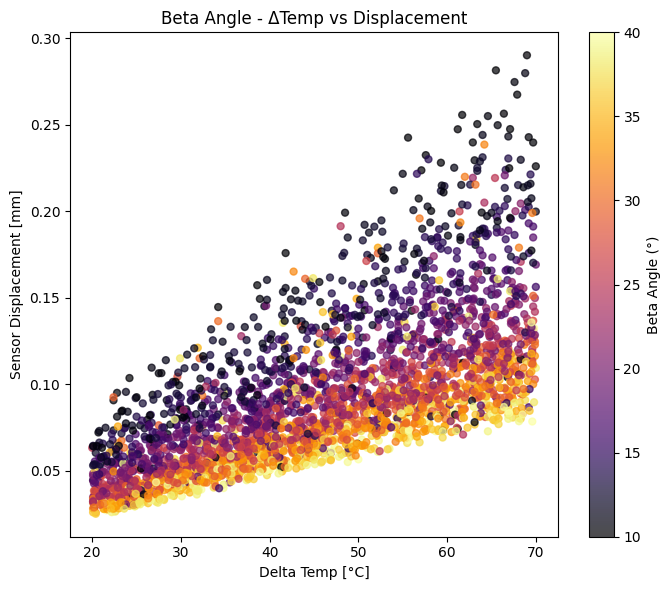

In [36]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    df["Delta Temp"],
    df["Sensor Displacement"],
    c=df["Beta Angle"], cmap="inferno", s=25, alpha=0.7
)
plt.xlabel("Delta Temp [°C]")
plt.ylabel("Sensor Displacement [mm]")
plt.title("Beta Angle - ΔTemp vs Displacement")
plt.colorbar(sc, label="Beta Angle (°)")
plt.tight_layout(); plt.show()

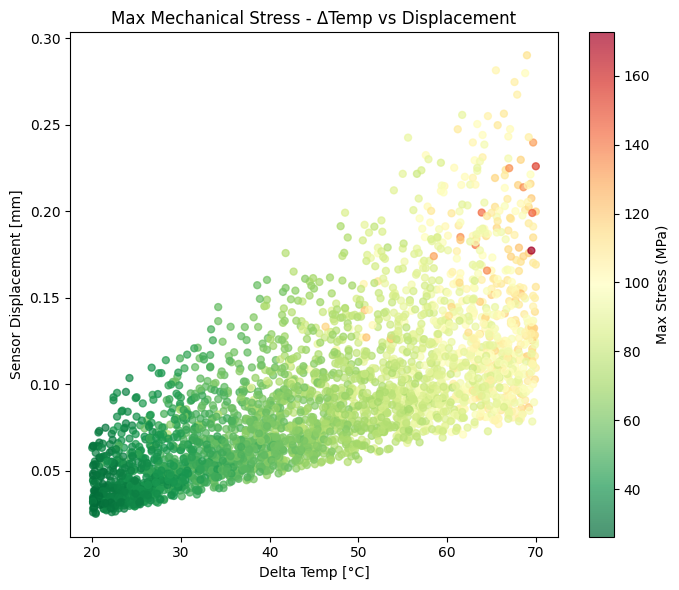

In [37]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    df["Delta Temp"],
    df["Sensor Displacement"],
    c=df["Max Mechanical Stress"], cmap="RdYlGn_r", s=25, alpha=0.7
)
plt.xlabel("Delta Temp [°C]")
plt.ylabel("Sensor Displacement [mm]")
plt.title("Max Mechanical Stress - ΔTemp vs Displacement")
plt.colorbar(sc, label="Max Stress (MPa)")
plt.tight_layout(); plt.show()